# 3D Cube Through a Camera — `ProjectionSpace` Demo

This notebook builds a full 3D → 2D camera pipeline using Coordinatus's
`ProjectionSpace`. The scene graph looks like this:

```
world (Space3D)
  └─ camera (Space — view transform)
       └─ screen (ProjectionSpace — perspective projection)
```

All cube vertices are defined in **world space**. To render them we call
`vertex.relative_to(screen)`, which automatically chains:
1. world → camera  (rigid view transform)
2. camera → screen (perspective projection via `ProjectionSpace`)

No manual matrix multiplications are needed outside the scene-graph setup.


## 1 — Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from coordinatus import Space3D, Space, Point, ProjectionSpace
from coordinatus.transforms.rotate import rotate3Dy
from coordinatus.transforms.translate import translate3D


## 2 — Define the 3D Cube Vertices and Edges

The cube is generated by a recursive **extrusion** algorithm:

| Step | Vertices |
|------|----------|
| 0D   | `[0]` — a single point |
| 1D   | `[[0], [1]]` — duplicate and shift by 1 in new dim |
| 2D   | `[[0,0], [0,1], [1,0], [1,1]]` — repeat |
| 3D   | `[[0,0,0], …, [1,1,1]]` — repeat |

Each extension duplicates all existing vertices: the first copy appends `0` in the new dimension, the second copy appends `1`. This yields $2^n$ vertices for an $n$-dimensional hypercube.

After centering (subtracting 0.5), every coordinate is in $\{-0.5,\ +0.5\}$.

**Edges** connect any two vertices whose indices differ by exactly one bit (Hamming distance = 1), which corresponds to neighbours along one axis. This gives $n \cdot 2^{n-1} = 12$ edges for a 3D cube.


In [2]:
def make_hypercube(n_dim: int) -> tuple[np.ndarray, list[tuple[int, int]]]:
    """Build vertices and edges of an n-dimensional unit hypercube centred at the origin.

    Algorithm:
      - Start with a single 0-dimensional point.
      - For each new dimension: duplicate all existing vertices, append 0 to
        the first half and 1 to the second half.
      - Centre by subtracting 0.5 from every coordinate.
      - Edges connect pairs whose vertex indices differ by exactly one bit.
    """
    vertices = np.zeros((1, 0))
    for _ in range(n_dim):
        low  = np.hstack([vertices, np.zeros((len(vertices), 1))])
        high = np.hstack([vertices, np.ones ((len(vertices), 1))])
        vertices = np.vstack([low, high])

    vertices -= 0.5  # centre at origin

    # Two vertices share an edge iff they are neighbours along exactly one axis,
    # which is equivalent to their indices differing by exactly one bit.
    n = 2 ** n_dim
    edges = [
        (i, j)
        for i in range(n)
        for j in range(i + 1, n)
        if bin(i ^ j).count("1") == 1
    ]
    return vertices, edges


VERTICES_XYZ, EDGES = make_hypercube(3)
print(f"Vertices: {len(VERTICES_XYZ)}, Edges: {len(EDGES)}")
print("Vertices (x, y, z):")
for i, v in enumerate(VERTICES_XYZ):
    print(f"  {i}: {v}")


Vertices: 8, Edges: 12
Vertices (x, y, z):
  0: [-0.5 -0.5 -0.5]
  1: [ 0.5 -0.5 -0.5]
  2: [-0.5  0.5 -0.5]
  3: [ 0.5  0.5 -0.5]
  4: [-0.5 -0.5  0.5]
  5: [ 0.5 -0.5  0.5]
  6: [-0.5  0.5  0.5]
  7: [0.5 0.5 0.5]


## 3 — Build the View Matrix (Camera Space)

The **view transform** moves world coordinates into camera coordinates.  
We place the camera at `eye`, looking toward `target`, with `up` pointing upward.  
The standard look-at construction gives three orthonormal basis vectors:

- **forward** = normalise(target − eye)
- **right**   = normalise(forward × up)
- **up′**     = right × forward  (re-orthogonalised)

Assembled into a 4x4 matrix this becomes the `camera` space transform.


In [3]:
def look_at(eye: np.ndarray, target: np.ndarray, up: np.ndarray) -> np.ndarray:
    """Return the 4x4 view matrix that transforms world coords into camera coords."""
    forward = target - eye
    forward = forward / np.linalg.norm(forward)

    right = np.cross(forward, up)
    right = right / np.linalg.norm(right)

    up_ortho = np.cross(right, forward)

    # Rotation part: rows are the camera's basis vectors
    R = np.array([
        [ right[0],    right[1],    right[2],   0],
        [ up_ortho[0], up_ortho[1], up_ortho[2], 0],
        [-forward[0], -forward[1], -forward[2],  0],
        [ 0,           0,           0,            1],
    ], dtype=float)

    # Translation: move world origin to the camera position
    T = translate3D(-eye[0], -eye[1], -eye[2])

    return R @ T


# ── Camera placement ──────────────────────────────────────────────────────────
eye    = np.array([2.0, 1.5, 3.0])   # camera position in world
target = np.array([0.0, 0.0, 0.0])   # looking at the cube centre
up     = np.array([0.0, 1.0, 0.0])   # world "up" direction

view_matrix = look_at(eye, target, up)
print("View matrix (4x4):")
print(np.round(view_matrix, 4))


View matrix (4x4):
[[ 0.8321  0.     -0.5547 -0.    ]
 [-0.2131  0.9233 -0.3196 -0.    ]
 [ 0.5121  0.3841  0.7682 -3.9051]
 [ 0.      0.      0.      1.    ]]


## 4 — Build the Perspective Projection Matrix

The classic perspective matrix maps camera-space points into **clip space**
(NDC after perspective divide). Given:

- `fov_y` — vertical field of view in radians  
- `aspect` — width / height  
- `near`, `far` — clipping plane distances  

$$
P = \begin{pmatrix}
\frac{f}{\text{aspect}} & 0 & 0 & 0 \\
0 & f & 0 & 0 \\
0 & 0 & \frac{\text{far}+\text{near}}{\text{near}-\text{far}} & \frac{2 \cdot \text{far} \cdot \text{near}}{\text{near}-\text{far}} \\
0 & 0 & -1 & 0
\end{pmatrix}
$$

where $f = \cot(\text{fov\_y} / 2)$.

This is a **non-square** 4x4 matrix that maps 3D → 3D clip coordinates (x, y, depth, w).  
A `ProjectionSpace` wraps it: its `projection_matrix` is exactly $P$.


In [4]:
def perspective_matrix(fov_y: float, aspect: float, near: float, far: float) -> np.ndarray:
    """Return the 4x4 perspective projection matrix (OpenGL convention)."""
    f = 1.0 / np.tan(fov_y / 2.0)
    return np.array([
        [f / aspect, 0,  0,                               0                              ],
        [0,          f,  0,                               0                              ],
        [0,          0, (far + near) / (near - far),  (2 * far * near) / (near - far)   ],
        [0,          0, -1,                              0                              ],
    ], dtype=float)


# ── Frustum parameters ────────────────────────────────────────────────────────
fov_y  = np.radians(60)   # 60° vertical field of view
aspect = 16 / 9           # widescreen aspect ratio
near   = 0.1
far    = 100.0

proj_matrix = perspective_matrix(fov_y, aspect, near, far)
print("Projection matrix (4x4):")
print(np.round(proj_matrix, 4))


Projection matrix (4x4):
[[ 0.9743  0.      0.      0.    ]
 [ 0.      1.7321  0.      0.    ]
 [ 0.      0.     -1.002  -0.2002]
 [ 0.      0.     -1.      0.    ]]


## 5 — Build the Scene Graph and Project the Cube

We assemble the three-level hierarchy:

```
world (Space3D)   — absolute reference
  └─ camera       — Space with view_matrix as transform
       └─ screen  — ProjectionSpace with proj_matrix
```

Each vertex is created as a `Point` in `world` space.  
`vertex.relative_to(screen)` traverses the LCA path automatically,
applying the view transform then the projection in one call.

After projection we perform the **perspective divide** (x/w, y/w) to obtain
normalised device coordinates (NDC) in [−1, 1].


In [5]:
# ── Scene graph ───────────────────────────────────────────────────────────────
world  = Space3D()
camera = Space(transform=view_matrix, parent=world)
screen = ProjectionSpace(projection_matrix=proj_matrix, parent=camera)

# ── Create all 8 cube vertices as Points in world space ───────────────────────
world_points = [Point(coords=v, space=world) for v in VERTICES_XYZ]

# ── Project each vertex through the scene graph ───────────────────────────────
# relative_to(screen) applies: world → camera (view) then camera → screen (proj)
clip_coords: list[np.ndarray] = []
for pt in world_points:
    clip = pt.relative_to(screen).coords   # shape (3,): [x_clip, y_clip, z_clip]
    clip_coords.append(clip)

# Perspective divide: NDC x = x_clip / w,  NDC y = y_clip / w
# The w component comes from the projection matrix's last row: w_clip = -z_cam
# We stored it in clip_coords[2] (z column carries the depth info).
# Reconstruct w from the homogeneous transform by re-applying the raw proj row.
def project_vertex(v_world: np.ndarray) -> tuple[float, float]:
    """Project a single world-space vertex to 2D NDC (x, y)."""
    h = np.append(v_world, 1.0)             # homogeneous world point
    cam_h = view_matrix @ h                 # camera space (homogeneous)
    clip_h = proj_matrix @ cam_h            # clip space: [x, y, z, w]
    w = clip_h[3]
    if abs(w) < 1e-9:
        return (0.0, 0.0)
    return (clip_h[0] / w, clip_h[1] / w)  # NDC


ndc_vertices = [project_vertex(v) for v in VERTICES_XYZ]
print("NDC coordinates (x, y) for each vertex:")
for i, (x, y) in enumerate(ndc_vertices):
    print(f"  v{i}: ({x:+.4f}, {y:+.4f})")


NDC coordinates (x, y) for each vertex:
  v0: (-0.0285, -0.0714)
  v1: (+0.1599, -0.1674)
  v2: (-0.0310, +0.2896)
  v3: (+0.1759, +0.2322)
  v4: (-0.1702, -0.2247)
  v5: (+0.0391, -0.3647)
  v6: (-0.1884, +0.1973)
  v7: (+0.0440, +0.1101)


## 6 — Render the Cube (Animated)

The cube rotates around the **world Y axis** — each frame applies `rotate3Dy(θ)` to
the vertices before projecting.

The figure is rendered in **16:9** to match the projection frustum's aspect ratio.


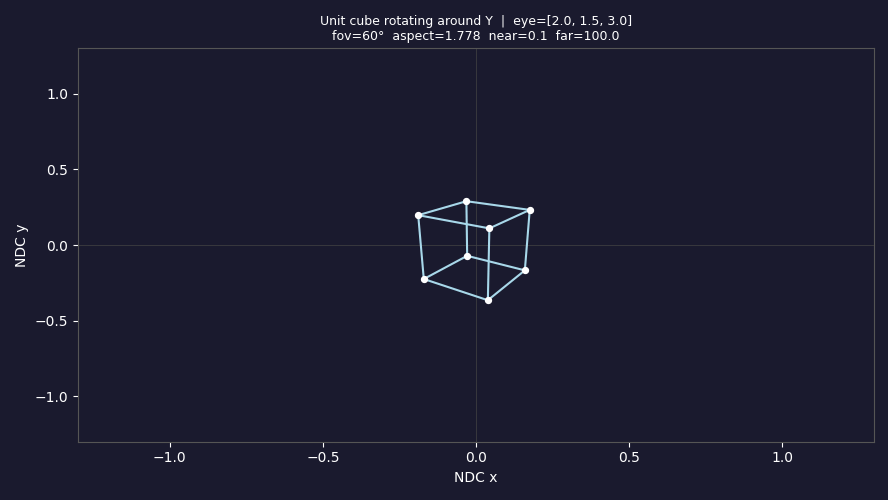

In [6]:
import tempfile
from pathlib import Path
from IPython.display import Image, display

N_FRAMES = 15   # one full revolution
FPS      = 30

# ── Figure: 16:9 to match the camera frustum aspect ratio ─────────────────
fig, ax = plt.subplots(figsize=(16 / 9 * 5, 5))
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#1a1a2e")

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect("auto")
ax.axhline(0, color="#444", linewidth=0.5)
ax.axvline(0, color="#444", linewidth=0.5)
ax.set_xlabel("NDC x", color="white")
ax.set_ylabel("NDC y", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#555")

ax.set_title(
    f"Unit cube rotating around Y  |  eye={eye.tolist()}\n"
    f"fov={np.degrees(fov_y):.0f}°  aspect={aspect:.3f}  near={near}  far={far}",
    color="white", fontsize=9,
)

# ── Pre-create one matplotlib Line2D per edge ──────────────────────────────
lines: list = []
for _ in EDGES:
    line, = ax.plot([], [], color="#a8d8ea", linewidth=1.5)
    lines.append(line)

scatter = ax.scatter([], [], color="white", s=18, zorder=5)

# ── Helpers ──────────────────────────────────────────────────────────────────────────────
def project_rotated(angle: float) -> list[tuple[float, float]]:
    """Project cube vertices after rotating them by `angle` around the world Y axis."""
    R = rotate3Dy(angle)
    result = []
    for v in VERTICES_XYZ:
        v_rot = (R @ np.append(v, 1.0))[:3]
        result.append(project_vertex(v_rot))
    return result

# ── Animation callbacks ──────────────────────────────────────────────────────────────
def init():
    for line in lines:
        line.set_data([], [])
    scatter.set_offsets(np.empty((0, 2)))
    return [*lines, scatter]

def update(frame: int):
    angle = frame * np.pi / 2 / N_FRAMES
    ndc = project_rotated(angle)
    for line, (i, j) in zip(lines, EDGES):
        x0, y0 = ndc[i]
        x1, y1 = ndc[j]
        line.set_data([x0, x1], [y0, y1])
    scatter.set_offsets(np.array(ndc))
    return [*lines, scatter]

anim = FuncAnimation(
    fig, update, frames=N_FRAMES, init_func=init,
    interval=1000 / FPS, blit=True,
)

plt.tight_layout()
plt.close()

# Save as GIF: deterministic bytes (no random IDs), renders natively on GitHub
with tempfile.NamedTemporaryFile(suffix=".gif", delete=False) as tmp:
    gif_path = Path(tmp.name)

anim.save(gif_path, writer="pillow", fps=FPS)
display(Image(data=gif_path.read_bytes(), format="gif"))
gif_path.unlink()
